In [2]:
import os
import sys

# Get the project root directory
PROJECT_ROOT = os.path.abspath("..")

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from src.logger import logger
from src.exception import BankChurnException
from src.components.data_ingestion import load_local_data

In [3]:
PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [4]:
RAW_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw",
    "Customer-Churn-Records.csv"
)

df = pd.read_csv(RAW_DATA_PATH)

logger.info(
    f"EDA started. Dataset shape: {df.shape}"
)

print(f"Dataset shape: {df.shape}")

Dataset shape: (10000, 18)


In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [6]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0,0,3,DIAMOND,911


In [7]:
df.sample(10, random_state=42)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
6252,6253,15687492,Anderson,596,Germany,Male,32,3,96709.07,2,0,0,41788.37,0,0,1,GOLD,709
4684,4685,15736963,Herring,623,France,Male,43,1,0.00,2,1,1,146379.30,0,0,2,SILVER,508
1731,1732,15721730,Amechi,601,Spain,Female,44,4,0.00,2,1,0,58561.31,0,0,1,GOLD,281
4742,4743,15762134,Liang,506,Germany,Male,59,8,119152.10,2,1,1,170679.74,0,0,2,SILVER,979
4521,4522,15648898,Chuang,560,Spain,Female,27,7,124995.98,1,1,1,114669.79,0,0,5,SILVER,457
6340,6341,15659064,Salas,790,Spain,Male,37,8,0.00,2,1,1,149418.41,0,0,4,GOLD,348
576,577,15761986,Obialo,439,Spain,Female,32,3,138901.61,1,1,0,75685.97,0,0,4,DIAMOND,913
5202,5203,15713354,Morrice,597,Germany,Female,22,6,101528.61,1,1,0,70529.00,1,1,2,SILVER,793
6363,6364,15593454,Lambert,678,Spain,Female,40,4,113794.22,1,1,0,16618.76,0,0,4,PLATINUM,831
439,440,15690134,Hughes,464,Germany,Female,42,3,85679.25,1,1,1,164104.74,0,0,3,SILVER,665


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 18


In [10]:
print("Columns:")
for column in df.columns:
    print(column)

Columns:
RowNumber
CustomerId
Surname
CreditScore
Geography
Gender
Age
Tenure
Balance
NumOfProducts
HasCrCard
IsActiveMember
EstimatedSalary
Exited
Complain
Satisfaction Score
Card Type
Point Earned


In [11]:
data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique().values
})

data_types

,Column,Data Type,Unique Values
RowNumber,RowNumber,int64,10000
CustomerId,CustomerId,int64,10000
Surname,Surname,str,2932
CreditScore,CreditScore,int64,460
Geography,Geography,str,3
Gender,Gender,str,2
Age,Age,int64,70
Tenure,Tenure,int64,11
Balance,Balance,float64,6382
NumOfProducts,NumOfProducts,int64,4


In [12]:
missing_analysis = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_analysis = (
    missing_analysis
    .sort_values(
        "Missing Count",
        ascending=False
    )
)

missing_analysis

,Missing Count,Missing Percentage
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


In [13]:
total_missing = df.isnull().sum().sum()

print(
    f"Total missing values: {total_missing}"
)

Total missing values: 0


In [14]:
duplicate_rows = df.duplicated().sum()

print(
    f"Duplicate rows: {duplicate_rows}"
)

Duplicate rows: 0


In [15]:
duplicate_customer_ids = df["CustomerId"].duplicated().sum()

print(
    f"Duplicate CustomerId values: {duplicate_customer_ids}"
)

Duplicate CustomerId values: 0


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [17]:
df.describe(
    include="object"
).T

C:\Users\jjsin\AppData\Local\Temp\ipykernel_8180\1936305823.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(


,count,unique,top,freq
Surname,10000,2932,Smith,32
Geography,10000,3,France,5014
Gender,10000,2,Male,5457
Card Type,10000,4,DIAMOND,2507


In [18]:
cardinality = (
    df.nunique()
    .sort_values(ascending=False)
    .to_frame("Unique Values")
)

cardinality

,Unique Values
RowNumber,10000
CustomerId,10000
EstimatedSalary,9999
Balance,6382
Surname,2932
Point Earned,785
CreditScore,460
Age,70
Tenure,11
Satisfaction Score,5


In [19]:
target_counts = df["Exited"].value_counts()

target_counts

Exited
0    7962
1    2038
Name: count, dtype: int64

In [20]:
target_percentages = (
    df["Exited"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_percentages

Exited
0    79.62
1    20.38
Name: proportion, dtype: float64

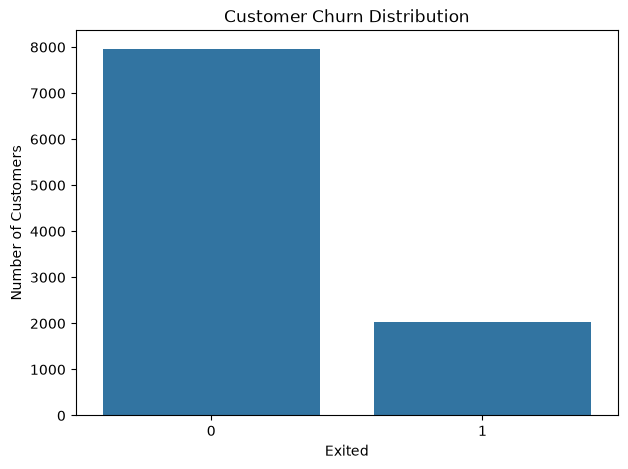

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Exited"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
churn_rate = df["Exited"].mean() * 100

print(
    f"Overall churn rate: {churn_rate:.2f}%"
)

Overall churn rate: 20.38%


In [23]:
numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "Point Earned"
]

In [24]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Point Earned,10000.0,606.515100,225.924839,119.00,410.00,605.000,801.0000,1000.00


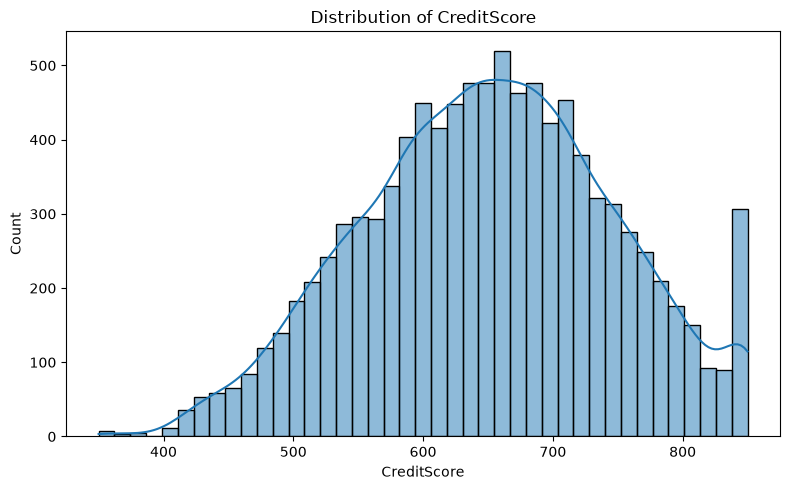

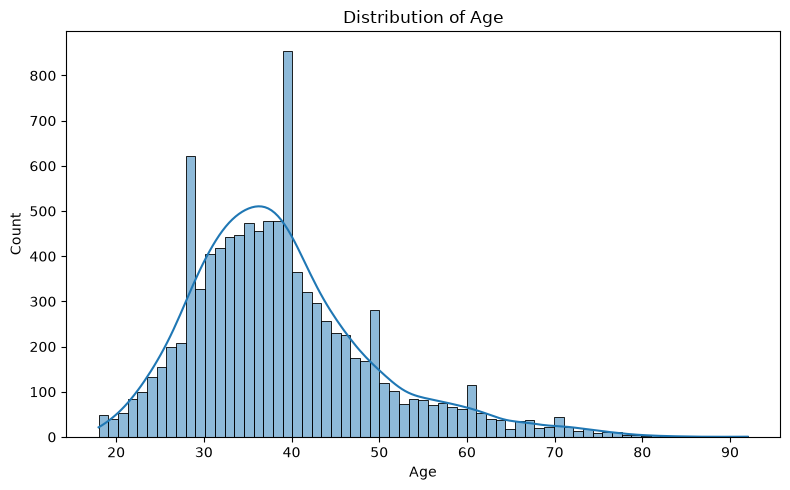

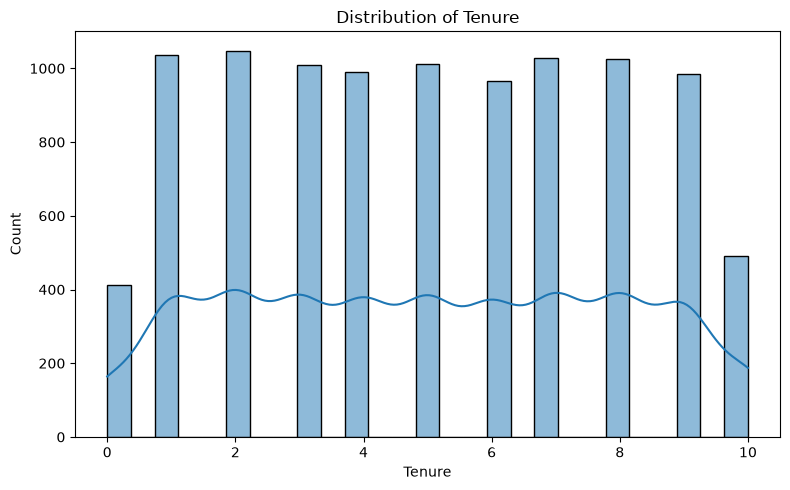

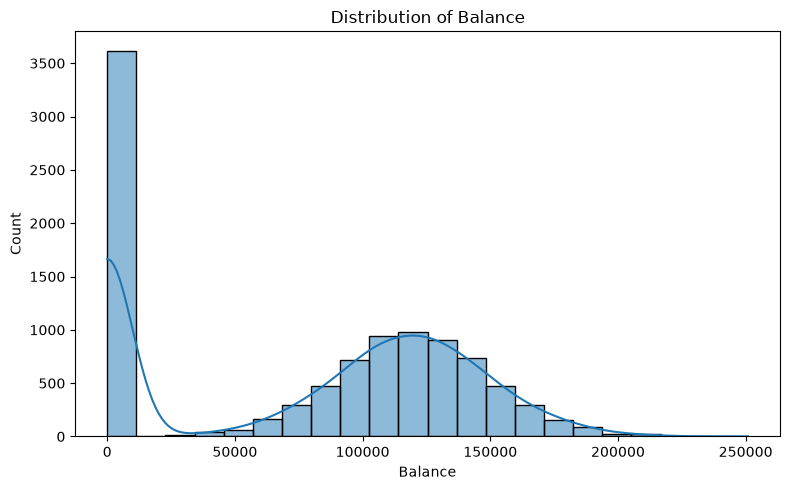

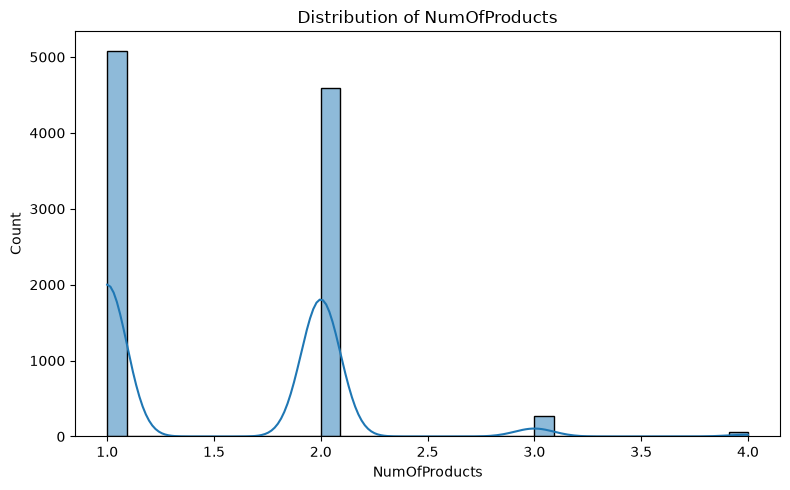

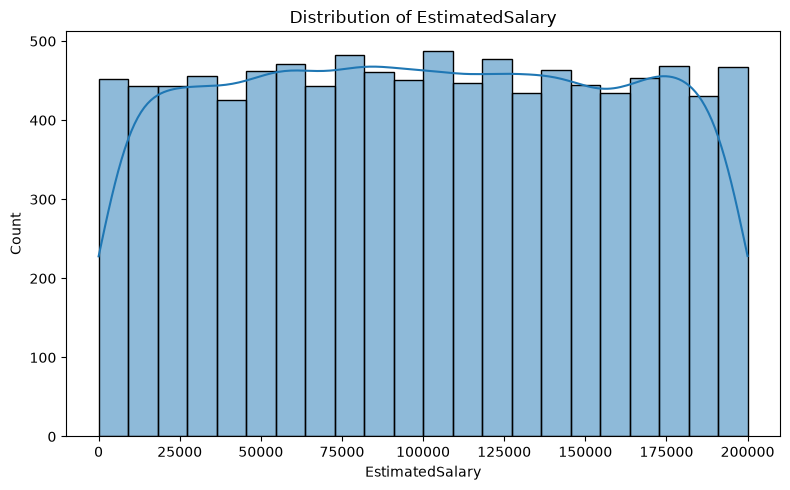

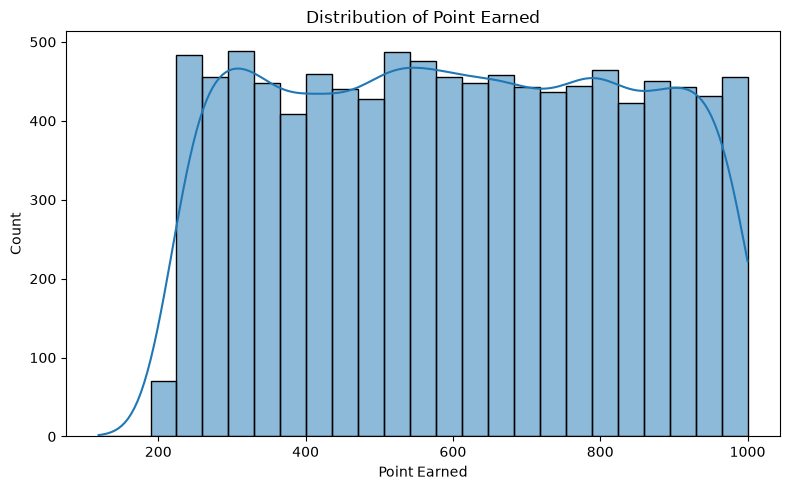

In [25]:
for column in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(
        f"Distribution of {column}"
    )

    plt.tight_layout()
    plt.show()

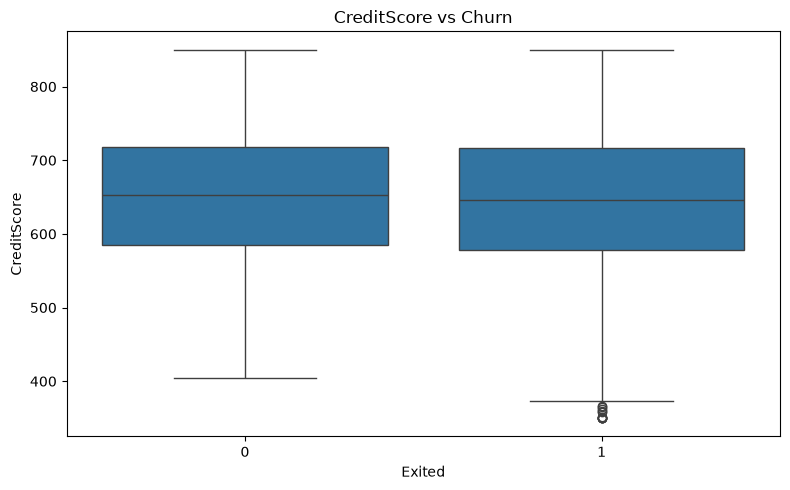

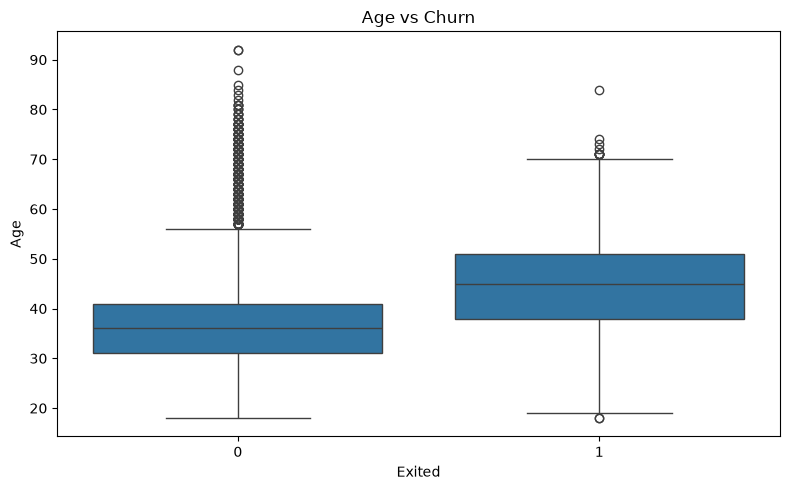

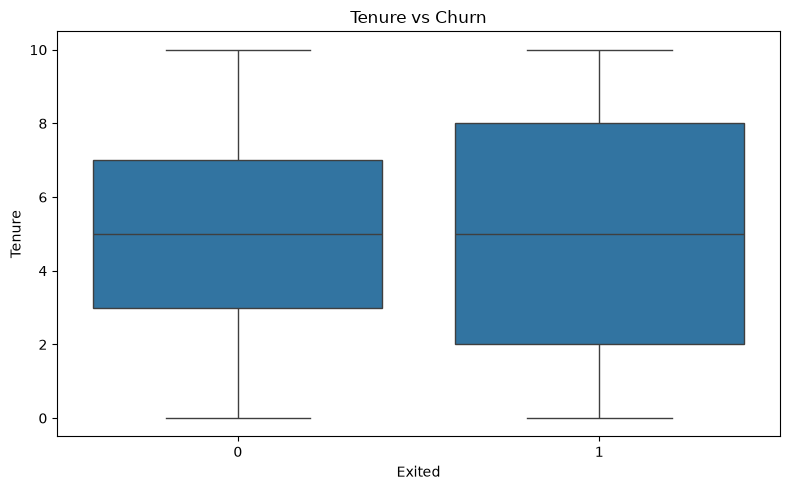

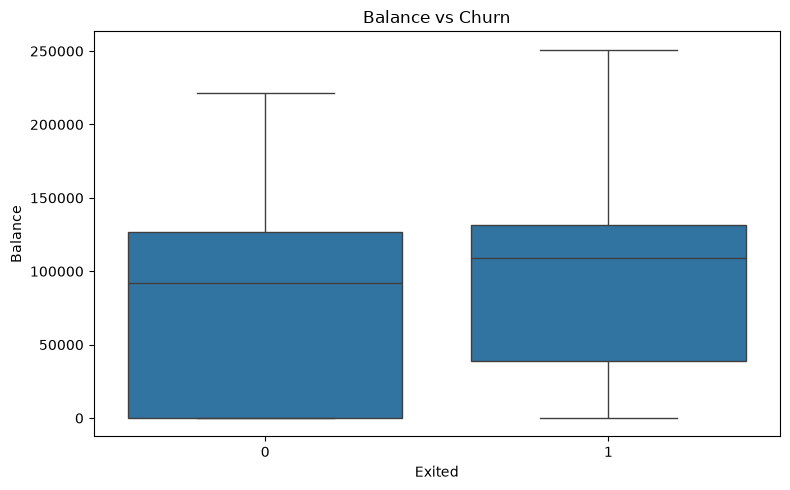

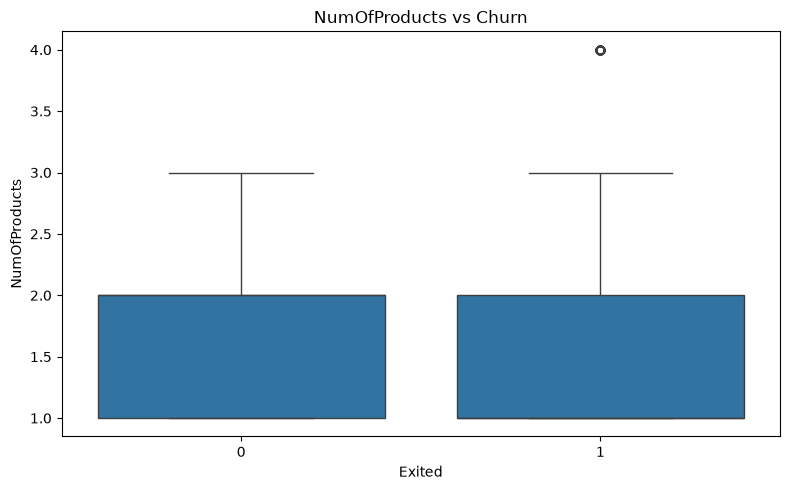

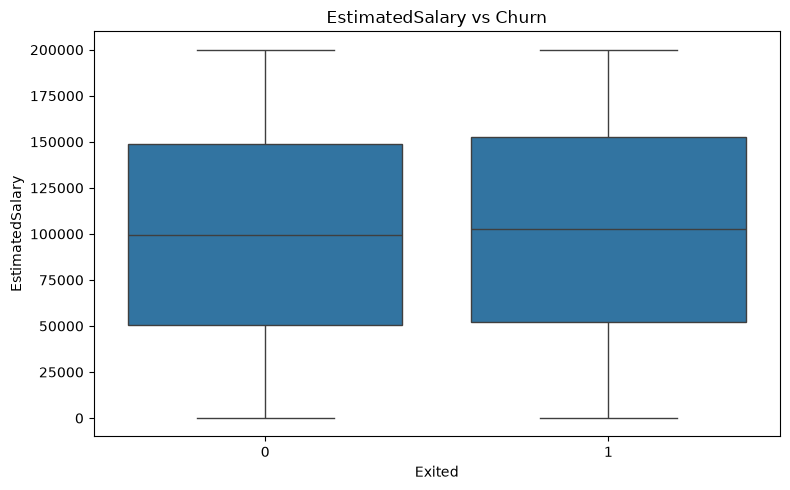

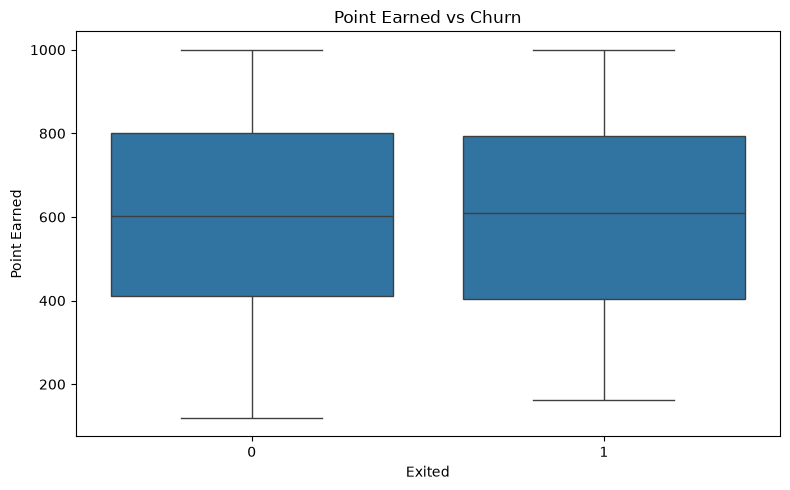

In [26]:
for column in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Exited",
        y=column
    )

    plt.title(
        f"{column} vs Churn"
    )

    plt.tight_layout()
    plt.show()

In [27]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"
    ]
)

In [28]:
age_churn = (
    df.groupby(
        "AgeGroup",
        observed=True
    )["Exited"]
    .mean()
    .mul(100)
)

age_churn

AgeGroup
18-25     7.528642
26-35     8.498024
36-45    19.646681
46-55    50.572082
56-65    48.320896
66+      13.257576
Name: Exited, dtype: float64

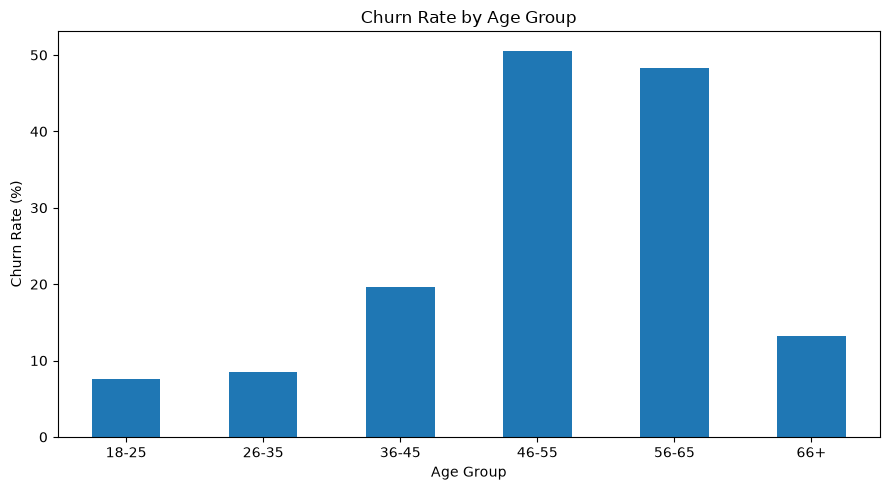

In [29]:
plt.figure(figsize=(9, 5))

age_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
categorical_features = [
    "Geography",
    "Gender",
    "Card Type"
]

In [31]:
for column in categorical_features:

    print(f"\n{column}")
    print(df[column].value_counts())


Geography
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Card Type
Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64


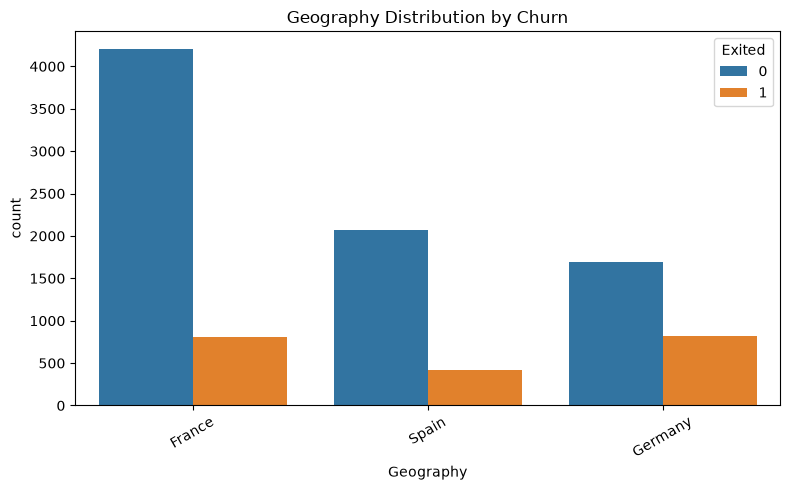

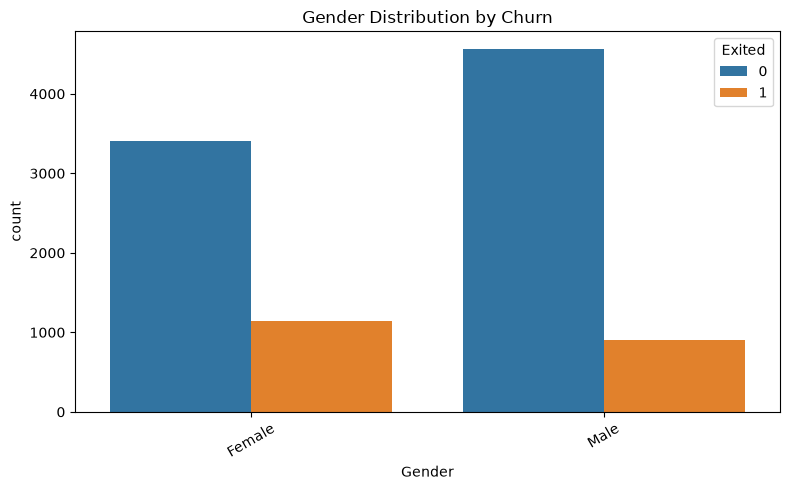

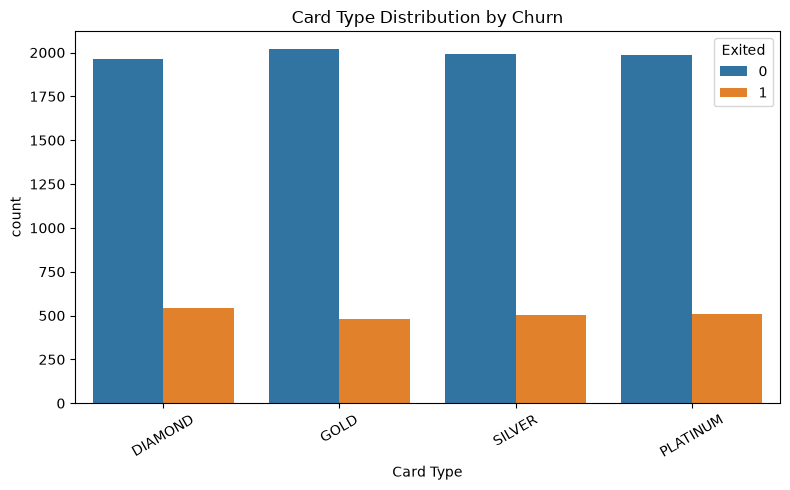

In [32]:
for column in categorical_features:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=column,
        hue="Exited"
    )

    plt.title(
        f"{column} Distribution by Churn"
    )

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [33]:
for column in categorical_features:

    churn_rate_by_category = (
        df.groupby(column)["Exited"]
        .mean()
        .mul(100)
        .sort_values(
            ascending=False
        )
    )

    print(
        f"\nChurn Rate by {column}:"
    )

    print(
        churn_rate_by_category
    )


Churn Rate by Geography:
Geography
Germany    32.443204
Spain      16.673395
France     16.174711
Name: Exited, dtype: float64

Churn Rate by Gender:
Gender
Female    25.071539
Male      16.474253
Name: Exited, dtype: float64

Churn Rate by Card Type:
Card Type
DIAMOND     21.779019
PLATINUM    20.360721
SILVER      20.112179
GOLD        19.264588
Name: Exited, dtype: float64


In [34]:
binary_features = [
    "HasCrCard",
    "IsActiveMember",
    "Complain"
]

In [35]:
for column in binary_features:

    result = (
        df.groupby(column)["Exited"]
        .agg(
            Customers="count",
            Churn_Rate="mean"
        )
    )

    result["Churn_Rate"] *= 100

    print(
        f"\n{column}"
    )

    display(result)


HasCrCard


,Customers,Churn_Rate
HasCrCard,,
0,2945,20.814941
1,7055,20.198441



IsActiveMember


,Customers,Churn_Rate
IsActiveMember,,
0,4849,26.871520
1,5151,14.269074



Complain


,Customers,Churn_Rate
Complain,,
0,7956,0.050277
1,2044,99.510763


In [36]:
satisfaction_churn = (
    df.groupby(
        "Satisfaction Score"
    )["Exited"]
    .agg(
        Customers="count",
        Churn_Rate="mean"
    )
)

satisfaction_churn["Churn_Rate"] *= 100

satisfaction_churn

,Customers,Churn_Rate
Satisfaction Score,,
1,1932,20.031056
2,2014,21.797418
3,2042,19.637610
4,2008,20.617530
5,2004,19.810379


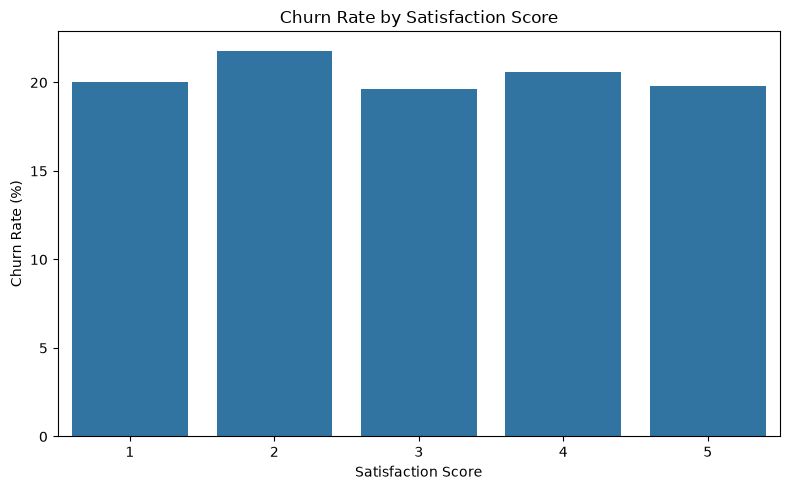

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=satisfaction_churn.reset_index(),
    x="Satisfaction Score",
    y="Churn_Rate"
)

plt.title(
    "Churn Rate by Satisfaction Score"
)

plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [38]:
products_churn = (
    df.groupby(
        "NumOfProducts"
    )["Exited"]
    .agg(
        Customers="count",
        Churn_Rate="mean"
    )
)

products_churn["Churn_Rate"] *= 100

products_churn

,Customers,Churn_Rate
NumOfProducts,,
1,5084,27.714398
2,4590,7.603486
3,266,82.706767
4,60,100.000000


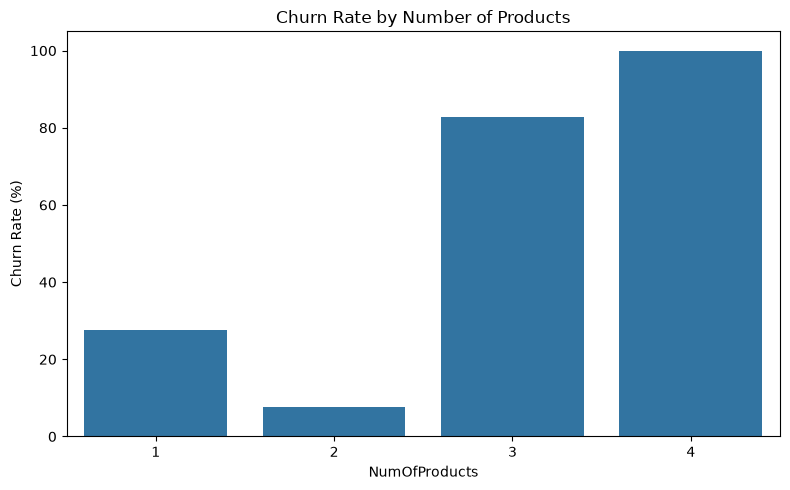

In [39]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=products_churn.reset_index(),
    x="NumOfProducts",
    y="Churn_Rate"
)

plt.title(
    "Churn Rate by Number of Products"
)

plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [40]:
correlation_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Exited",
    "Complain",
    "Satisfaction Score",
    "Point Earned"
]

In [41]:
correlation_matrix = (
    df[correlation_features]
    .corr()
)

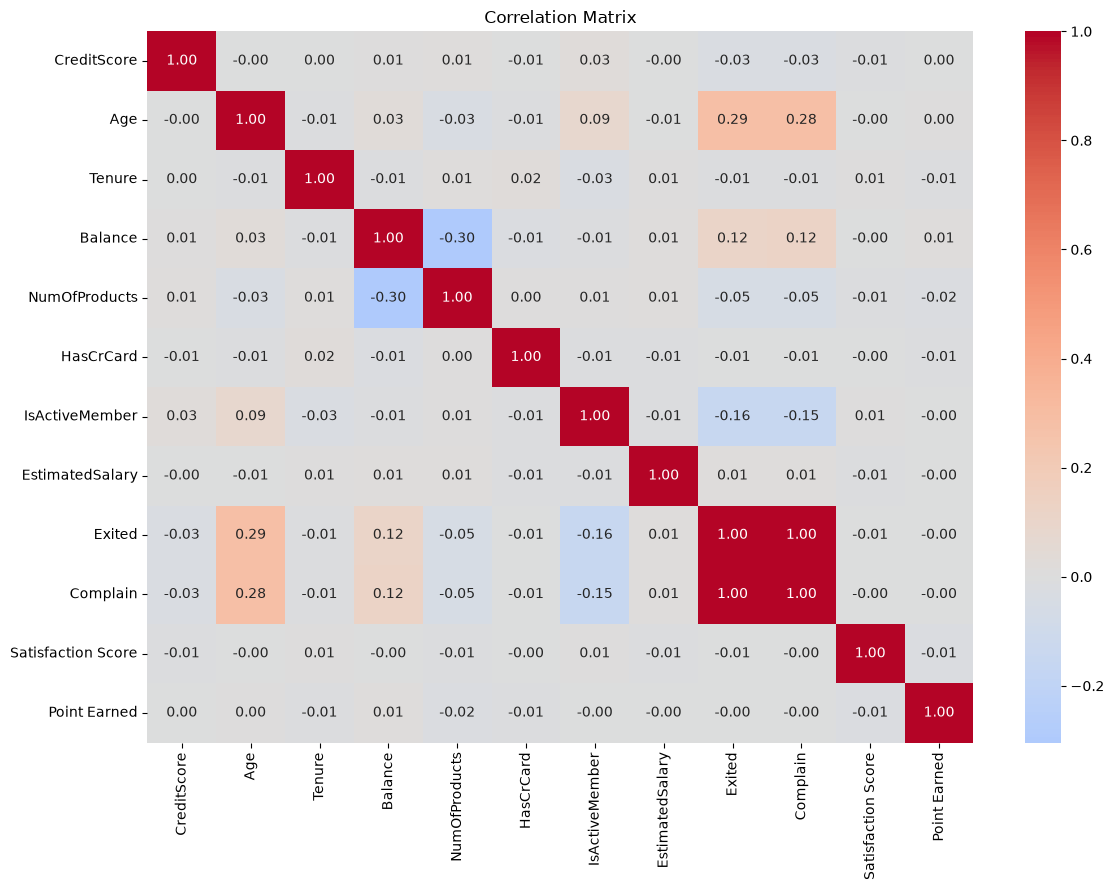

In [42]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix"
)

plt.tight_layout()
plt.show()

In [43]:
geo_gender_churn = pd.pivot_table(
    df,
    values="Exited",
    index="Geography",
    columns="Gender",
    aggfunc="mean"
) * 100

geo_gender_churn

Gender,Female,Male
Geography,,
France,20.344980,12.749728
Germany,37.552389,27.811550
Spain,21.212121,13.112392


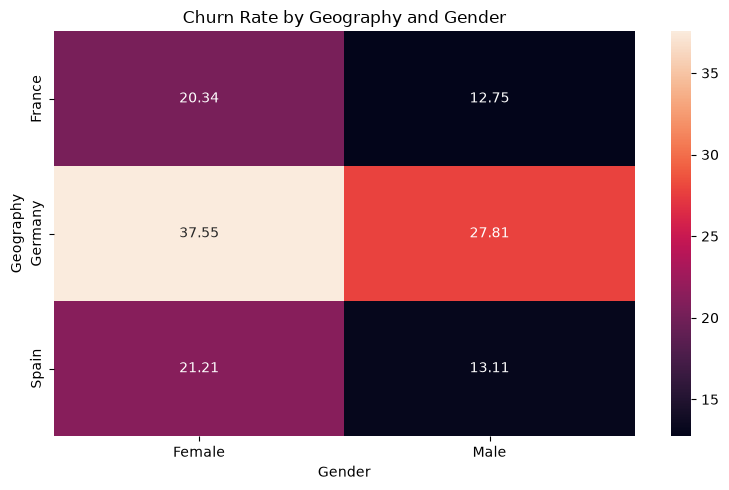

In [44]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    geo_gender_churn,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Churn Rate by Geography and Gender"
)

plt.ylabel("Geography")
plt.xlabel("Gender")

plt.tight_layout()
plt.show()

In [45]:
active_complaint = pd.pivot_table(
    df,
    values="Exited",
    index="IsActiveMember",
    columns="Complain",
    aggfunc="mean"
) * 100

active_complaint

Complain,0,1
IsActiveMember,,
0,0.112803,99.693016
1,0.000000,99.190283


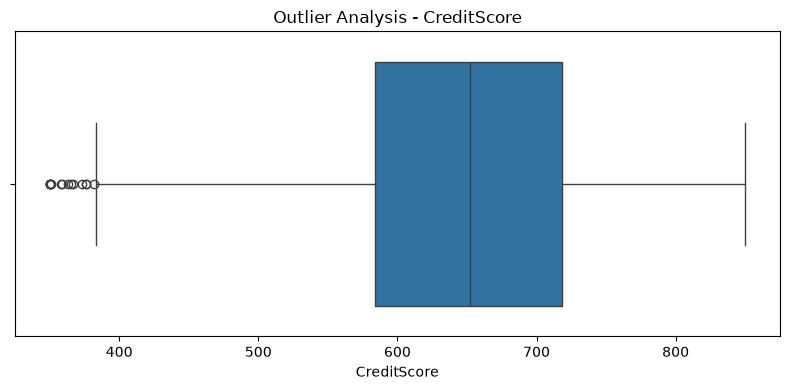

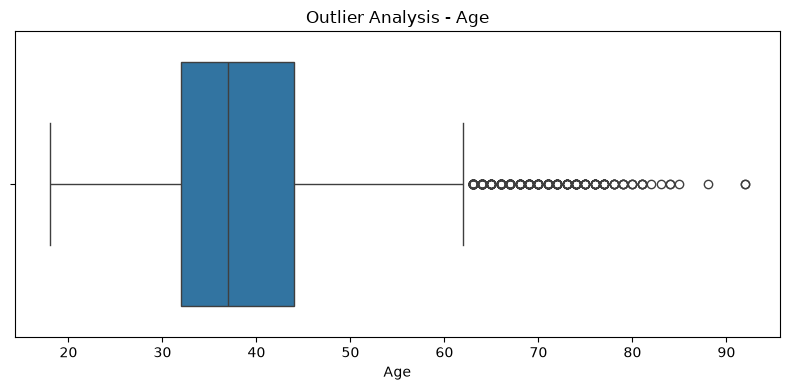

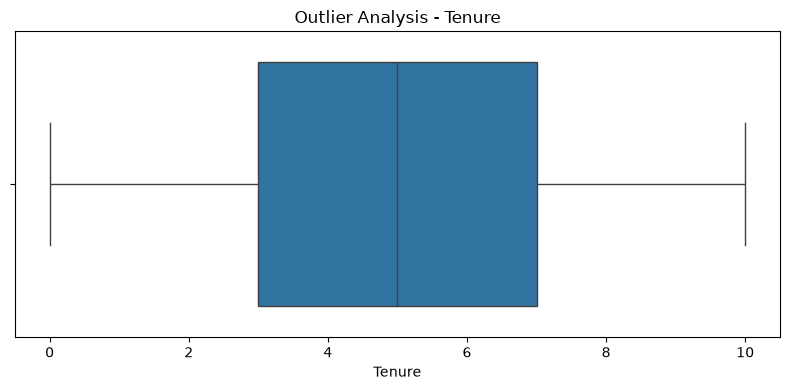

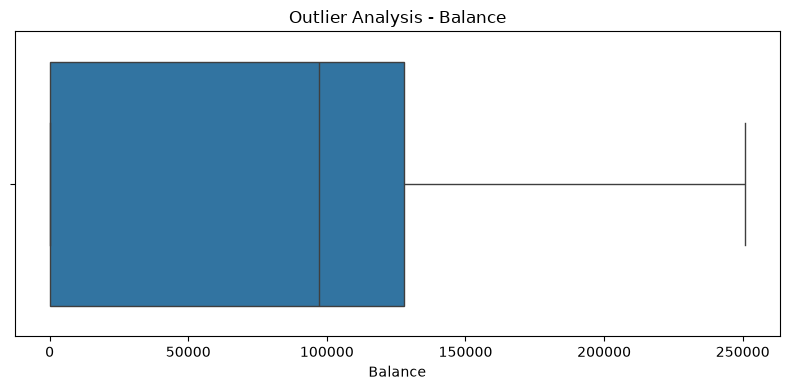

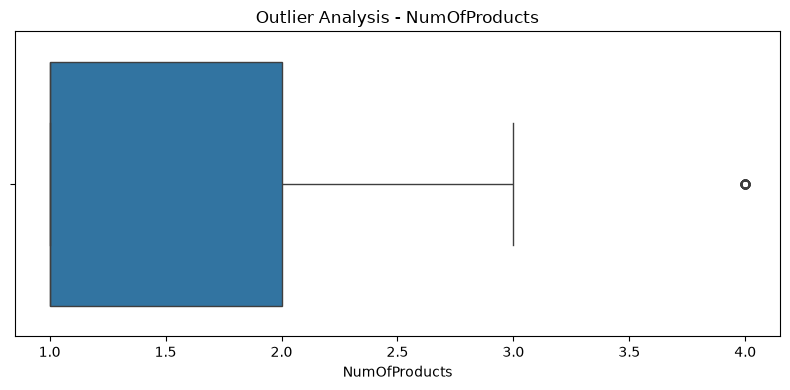

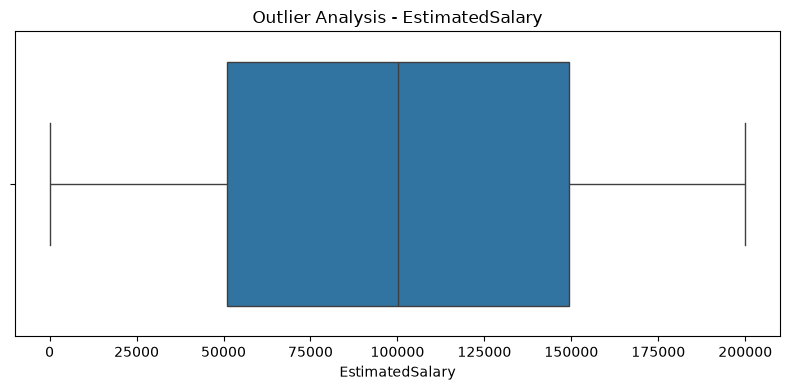

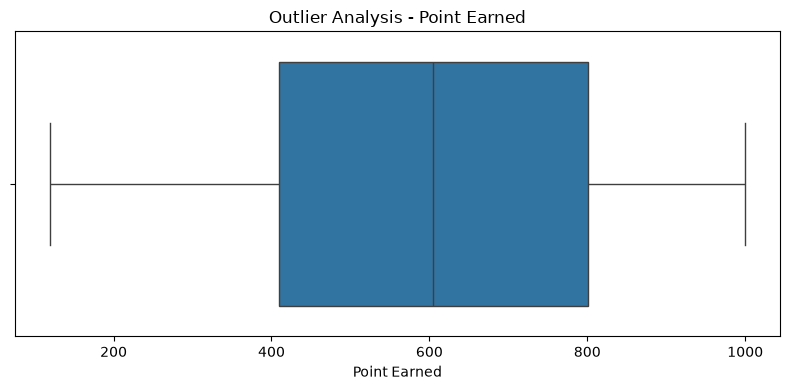

In [46]:
for column in numerical_features:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(
        f"Outlier Analysis - {column}"
    )

    plt.tight_layout()
    plt.show()

In [47]:
feature_assessment = pd.DataFrame({
    "Feature": [
        "RowNumber",
        "CustomerId",
        "Surname",
        "CreditScore",
        "Geography",
        "Gender",
        "Age",
        "Tenure",
        "Balance",
        "NumOfProducts",
        "HasCrCard",
        "IsActiveMember",
        "EstimatedSalary",
        "Exited",
        "Complain",
        "Satisfaction Score",
        "Card Type",
        "Point Earned"
    ],
    "Role": [
        "Identifier",
        "Identifier",
        "High-cardinality categorical",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Target",
        "Feature - investigate leakage",
        "Feature",
        "Feature",
        "Feature"
    ]
})

feature_assessment

,Feature,Role
0,RowNumber,Identifier
1,CustomerId,Identifier
2,Surname,High-cardinality categorical
3,CreditScore,Feature
4,Geography,Feature
5,Gender,Feature
6,Age,Feature
7,Tenure,Feature
8,Balance,Feature
9,NumOfProducts,Feature


In [49]:
candidate_features = [
    "CreditScore",
    "Geography",
    "Gender",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Complain",
    "Satisfaction Score",
    "Card Type",
    "Point Earned"
]

excluded_features = [
    "RowNumber",
    "CustomerId",
    "Surname"
]

target = "Exited"

In [50]:
EDA_SUMMARY_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "interim",
    "eda_summary.txt"
)

os.makedirs(
    os.path.dirname(EDA_SUMMARY_PATH),
    exist_ok=True
)

with open(
    EDA_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        f"Dataset Shape: {df.shape}\n"
    )

    file.write(
        f"Missing Values: {df.isnull().sum().sum()}\n"
    )

    file.write(
        f"Duplicate Rows: {df.duplicated().sum()}\n"
    )

    file.write(
        f"Churn Rate: {df['Exited'].mean() * 100:.2f}%\n"
    )

    file.write(
        f"Features: {candidate_features}\n"
    )

print(
    f"EDA summary saved to: {EDA_SUMMARY_PATH}"
)

EDA summary saved to: e:\Bank customer\bank-customer-churn\data\interim\eda_summary.txt


In [52]:
# ============================================================
# EDA RESULTS FOR MODELING DECISIONS
# ============================================================

print("=" * 70)
print("BANK CUSTOMER CHURN - KEY EDA RESULTS")
print("=" * 70)


# 1. Dataset shape
print("\n1. DATASET SHAPE")
print("-" * 70)
print(df.shape)


# 2. Total missing values
print("\n2. TOTAL MISSING VALUES")
print("-" * 70)
print(df.isnull().sum().sum())


# 3. Duplicate rows
print("\n3. DUPLICATE ROWS")
print("-" * 70)
print(df.duplicated().sum())


# 4. Duplicate CustomerId
print("\n4. DUPLICATE CUSTOMERID")
print("-" * 70)
print(df["CustomerId"].duplicated().sum())


# 5. Exited value counts + percentages
print("\n5. EXITED VALUE COUNTS + PERCENTAGES")
print("-" * 70)

exited_summary = pd.DataFrame({
    "Count": df["Exited"].value_counts().sort_index(),
    "Percentage": (
        df["Exited"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

print(exited_summary)


# 6. Churn rate by Complain
print("\n6. CHURN RATE BY COMPLAIN")
print("-" * 70)

complain_summary = (
    df.groupby("Complain")["Exited"]
    .agg(
        Customers="count",
        Churned="sum",
        Churn_Rate="mean"
    )
)

complain_summary["Churn_Rate"] = (
    complain_summary["Churn_Rate"] * 100
).round(2)

print(complain_summary)


# 7. Churn rate by Satisfaction Score
print("\n7. CHURN RATE BY SATISFACTION SCORE")
print("-" * 70)

satisfaction_summary = (
    df.groupby("Satisfaction Score")["Exited"]
    .agg(
        Customers="count",
        Churned="sum",
        Churn_Rate="mean"
    )
)

satisfaction_summary["Churn_Rate"] = (
    satisfaction_summary["Churn_Rate"] * 100
).round(2)

print(satisfaction_summary)


# 8. Churn rate by NumOfProducts
print("\n8. CHURN RATE BY NUMOFPRODUCTS")
print("-" * 70)

products_summary = (
    df.groupby("NumOfProducts")["Exited"]
    .agg(
        Customers="count",
        Churned="sum",
        Churn_Rate="mean"
    )
)

products_summary["Churn_Rate"] = (
    products_summary["Churn_Rate"] * 100
).round(2)

print(products_summary)


# 9. Churn rate by Geography
print("\n9. CHURN RATE BY GEOGRAPHY")
print("-" * 70)

geography_summary = (
    df.groupby("Geography")["Exited"]
    .agg(
        Customers="count",
        Churned="sum",
        Churn_Rate="mean"
    )
)

geography_summary["Churn_Rate"] = (
    geography_summary["Churn_Rate"] * 100
).round(2)

print(geography_summary)


# 10. Churn rate by IsActiveMember
print("\n10. CHURN RATE BY ISACTIVEMEMBER")
print("-" * 70)

active_member_summary = (
    df.groupby("IsActiveMember")["Exited"]
    .agg(
        Customers="count",
        Churned="sum",
        Churn_Rate="mean"
    )
)

active_member_summary["Churn_Rate"] = (
    active_member_summary["Churn_Rate"] * 100
).round(2)

print(active_member_summary)


print("\n" + "=" * 70)
print("END OF KEY EDA RESULTS")
print("=" * 70)

BANK CUSTOMER CHURN - KEY EDA RESULTS

1. DATASET SHAPE
----------------------------------------------------------------------
(10000, 19)

2. TOTAL MISSING VALUES
----------------------------------------------------------------------
0

3. DUPLICATE ROWS
----------------------------------------------------------------------
0

4. DUPLICATE CUSTOMERID
----------------------------------------------------------------------
0

5. EXITED VALUE COUNTS + PERCENTAGES
----------------------------------------------------------------------
        Count  Percentage
Exited                   
0        7962       79.62
1        2038       20.38

6. CHURN RATE BY COMPLAIN
----------------------------------------------------------------------
          Customers  Churned  Churn_Rate
Complain                                
0              7956        4        0.05
1              2044     2034       99.51

7. CHURN RATE BY SATISFACTION SCORE
-------------------------------------------------------------